# Intelligent Loan Analytics and Prediction System using Machine Learning

## Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to understand the HDFC Loan dataset, identify data quality issues, perform exploratory analysis, and prepare the data for machine learning model development.

### Dataset
Dataset: hdfc_loan_dataset_full_enriched.csv

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# Step 1: Import Required Libraries

In this step, we import all the necessary libraries required for data analysis and visualization.

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Step 2: Load Dataset

The dataset is loaded into a Pandas DataFrame for further analysis.

In [55]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
#Load dataset
data = pd.read_csv('/content/drive/MyDrive/Machine_Learning/datasets/hdfc_loan_dataset_full_enriched.csv')

# Step 3: View Dataset

Display the first few rows to understand the structure and contents of the dataset.

In [57]:
data.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,Positive,NaN,Hindu,Delhi,Dwarka,857743,6.939290e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,Negative,NaN,Hindu,Punjab,Ludhiana,863836,6.325430e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,Positive,NaN,Hindu,Maharashtra,Nagpur,834796,1.658050e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,Negative,NaN,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,Neutral,NaN,Sikh,West Bengal,Kolkata,495224,1.557790e+11,9795137116,harpreet.singh@example.in,Shopkeeper


### Observation

- The dataset contains customer demographic information, financial details, employment information, and loan-related attributes.
- Each row represents one customer loan application.
- The dataset includes both numerical and categorical features.
- The target column for Loan Approval Prediction is `Loan_Status`.
- The dataset contains a total of 48 columns.

# Step 4: Dataset Dimensions

Check the number of rows and columns present in the dataset.

In [58]:
print("Rows and Columns:", data.shape)

Rows and Columns: (1000, 48)


### Observation

The dataset contains 1000 rows and 48 columns.


# Step 5: Column Names

Display all available features in the dataset.

In [59]:
data.columns

Index(['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Dependents',
       'Education', 'Employment_Status', 'Applicant_Income',
       'Coapplicant_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_History', 'Property_Area', 'Age', 'Loan_Status', 'CIBIL_Score',
       'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Purpose_of_Loan',
       'Existing_EMIs', 'Number_of_Previous_Loans', 'Default_History_Count',
       'Employment_Length_Years', 'Business_Type', 'Asset_Value', 'Guarantor',
       'Co-signer_Relationship', 'Monthly_Expense', 'Organization_Type',
       'Region_Branch', 'Mobile_Verified', 'Email_Verified',
       'Institutional_Relationships', 'Application_Text', 'Customer_Feedback',
       'Agent_Notes', 'Loan_to_Annual_Income', 'Customer_Sentiment',
       'Unnamed: 39', 'Religion', 'State', 'City', 'PIN_Code',
       'Aadhaar_Synthetic', 'Phone_Number', 'Email', 'Occupation'],
      dtype='object')

# Step 6: Dataset Information

This step helps identify:
- Data types
- Number of non-null values
- Missing values

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

### Observation

- The dataset contains 1000 records and 48 columns.
- There are 21 numerical columns and 27 categorical columns.
- Most columns are complete and contain no missing values.
- Some columns contain missing values and require preprocessing.
- The dataset contains customer demographics, financial information, employment details, verification information, and loan history attributes.

# Step 7: Statistical Summary

Generate descriptive statistics for numerical columns.

In [61]:
data.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,...,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Asset_Value,Monthly_Expense,Loan_to_Annual_Income,Unnamed: 39,PIN_Code,Aadhaar_Synthetic,Phone_Number
count,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.00000,1.000000e+03,1000.000000,...,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,0.0,1000.00000,1.000000e+03,1.000000e+03
mean,0.849000,42430.057000,9727.11400,2.216713e+06,159.132000,0.72300,34.412000,653.01300,6.258861e+05,148.118157,...,0.865000,0.147000,2.434000,1.908042e+06,23603.427000,10.163103,NaN,509976.40800,4.853271e+11,9.500193e+09
std,0.964951,28133.210769,20568.25945,2.635021e+06,127.056704,0.44774,8.572616,73.83654,4.724545e+05,1974.599103,...,0.911925,0.499641,2.791673,1.481451e+06,18054.598235,25.415631,NaN,289145.26265,2.925326e+11,2.875105e+08
min,0.000000,0.000000,0.00000,1.884000e+03,12.000000,0.00000,18.000000,384.00000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.003000,NaN,622.00000,2.589553e+08,9.002443e+09
25%,0.000000,18260.000000,0.00000,3.729465e+05,36.000000,0.00000,28.000000,605.75000,2.639520e+05,0.031000,...,0.000000,0.000000,0.000000,7.424400e+05,9159.250000,0.645750,NaN,263067.50000,2.192082e+11,9.254018e+09
50%,1.000000,40675.500000,0.00000,9.720460e+05,120.000000,1.00000,35.000000,654.00000,5.512440e+05,0.332000,...,1.000000,0.000000,2.000000,1.634312e+06,20787.500000,2.309000,NaN,517643.50000,4.734835e+11,9.498140e+09
75%,2.000000,61037.250000,7956.50000,3.315038e+06,300.000000,1.00000,40.000000,704.00000,8.565480e+05,0.795000,...,1.000000,0.000000,3.000000,2.726302e+06,33067.750000,8.326750,NaN,756922.00000,7.303725e+11,9.750462e+09
max,3.000000,149266.000000,123461.00000,1.379096e+07,360.000000,1.00000,66.000000,878.00000,2.555340e+06,38342.000000,...,5.000000,3.000000,15.000000,7.742001e+06,97762.000000,269.754000,NaN,998910.00000,9.990010e+11,9.999102e+09


# Step 8: Missing Value Analysis

Identify columns containing missing values.

In [62]:
data.isnull().sum()

,0
Loan_ID,0
Bank,0
Customer_Name,0
Gender,0
Married,0
Dependents,0
Education,0
Employment_Status,0
Applicant_Income,0
Coapplicant_Income,0


### Observation

Missing values were identified in the following columns:

1. Business_Type → 799 missing values
2. Co-signer_Relationship → 234 missing values
3. Unnamed: 39 → 1000 missing values

Among these columns:

- `Unnamed: 39` contains only missing values and can be removed.
- `Business_Type` has a large number of missing values and requires further analysis.
- `Co-signer_Relationship` contains partial missing values which can be handled during preprocessing.

# Step 9: Duplicate Value Analysis

Check whether duplicate rows exist in the dataset.

In [63]:
data.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

# Step 10: Identify Numerical and Categorical Features

Separate numerical and categorical columns for further analysis.

In [64]:
numerical_columns = data.select_dtypes(include=np.number).columns
categorical_columns = data.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical_columns)


print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
       'Loan_Term_Months', 'Credit_History', 'Age', 'CIBIL_Score',
       'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Existing_EMIs',
       'Number_of_Previous_Loans', 'Default_History_Count',
       'Employment_Length_Years', 'Asset_Value', 'Monthly_Expense',
       'Loan_to_Annual_Income', 'Unnamed: 39', 'PIN_Code', 'Aadhaar_Synthetic',
       'Phone_Number'],
      dtype='object')
Categorical Columns:
Index(['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Education',
       'Employment_Status', 'Property_Area', 'Loan_Status', 'Purpose_of_Loan',
       'Business_Type', 'Guarantor', 'Co-signer_Relationship',
       'Organization_Type', 'Region_Branch', 'Mobile_Verified',
       'Email_Verified', 'Institutional_Relationships', 'Application_Text',
       'Customer_Feedback', 'Agent_Notes', 'Customer_Sentiment', 'Religion',
       'State', 'City', 'Email', 'Occupation'],
  

#=====EDA VISUALIZATONS=====

# Visualization 1: Loan Approval Distribution

This graph shows the number of approved and rejected loan applications.

/tmp/ipykernel_465/719967228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= 'Loan_Status', data=data, palette='pastel')


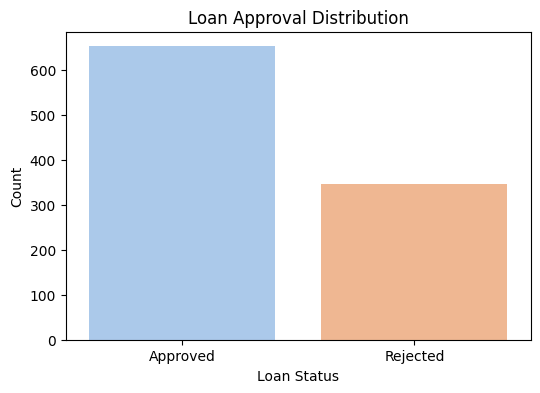

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(x= 'Loan_Status', data=data, palette='pastel')

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

### Observation

Most customers belong to the approved category.

# Visualization 2: Applicant Income Distribution

Analyze the spread of applicant incomes.

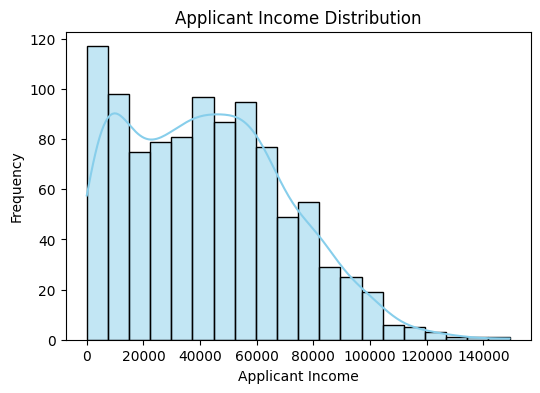

In [66]:
plt.figure(figsize=(6,4))

sns.histplot(data['Applicant_Income'], bins=20, kde=True, color='skyblue')

plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')

plt.show()

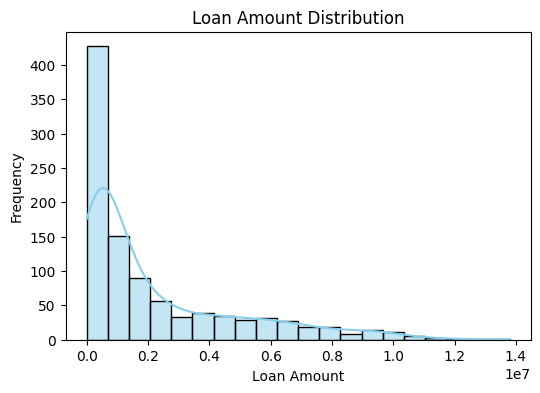

In [67]:
# Loan Amount distribution

plt.figure(figsize=(6,4))

sns.histplot(data['Loan_Amount'], bins=20, kde=True, color='skyblue')

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

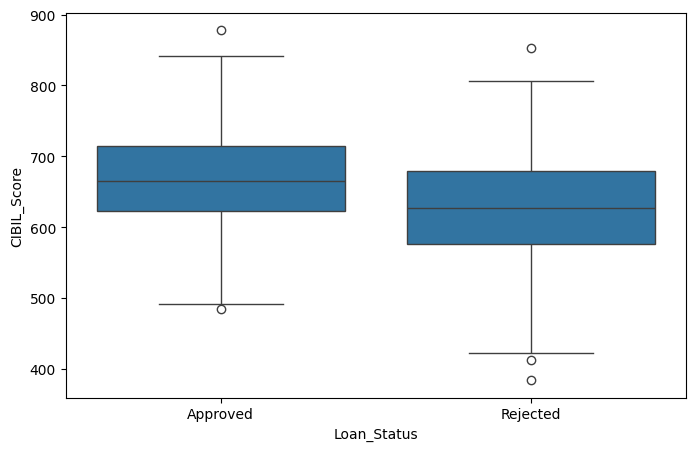

In [68]:
# CIBIL score vs Loan Status

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Loan_Status',
    y='CIBIL_Score',
    data=data
)

plt.show()

# Observation
Customers with higher CIBIL scores have a greater probability of loan approval.

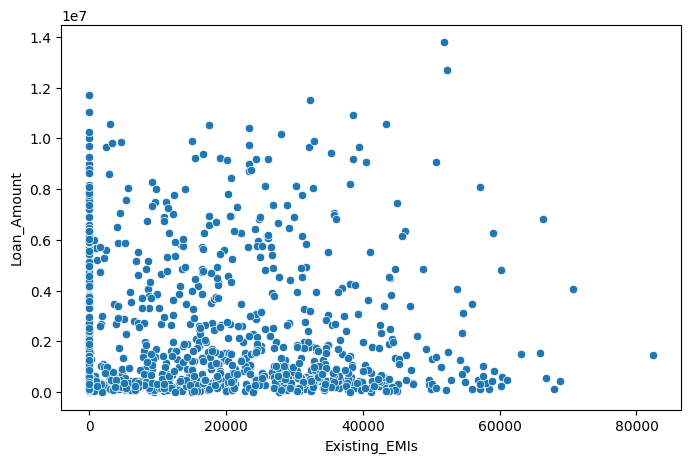

In [69]:
# Existing EMI vs Loan Amount

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Existing_EMIs',
    y='Loan_Amount',
    data=data
)

plt.show()

# Correlation Analysis

Correlation helps understand relationships between numerical variables.

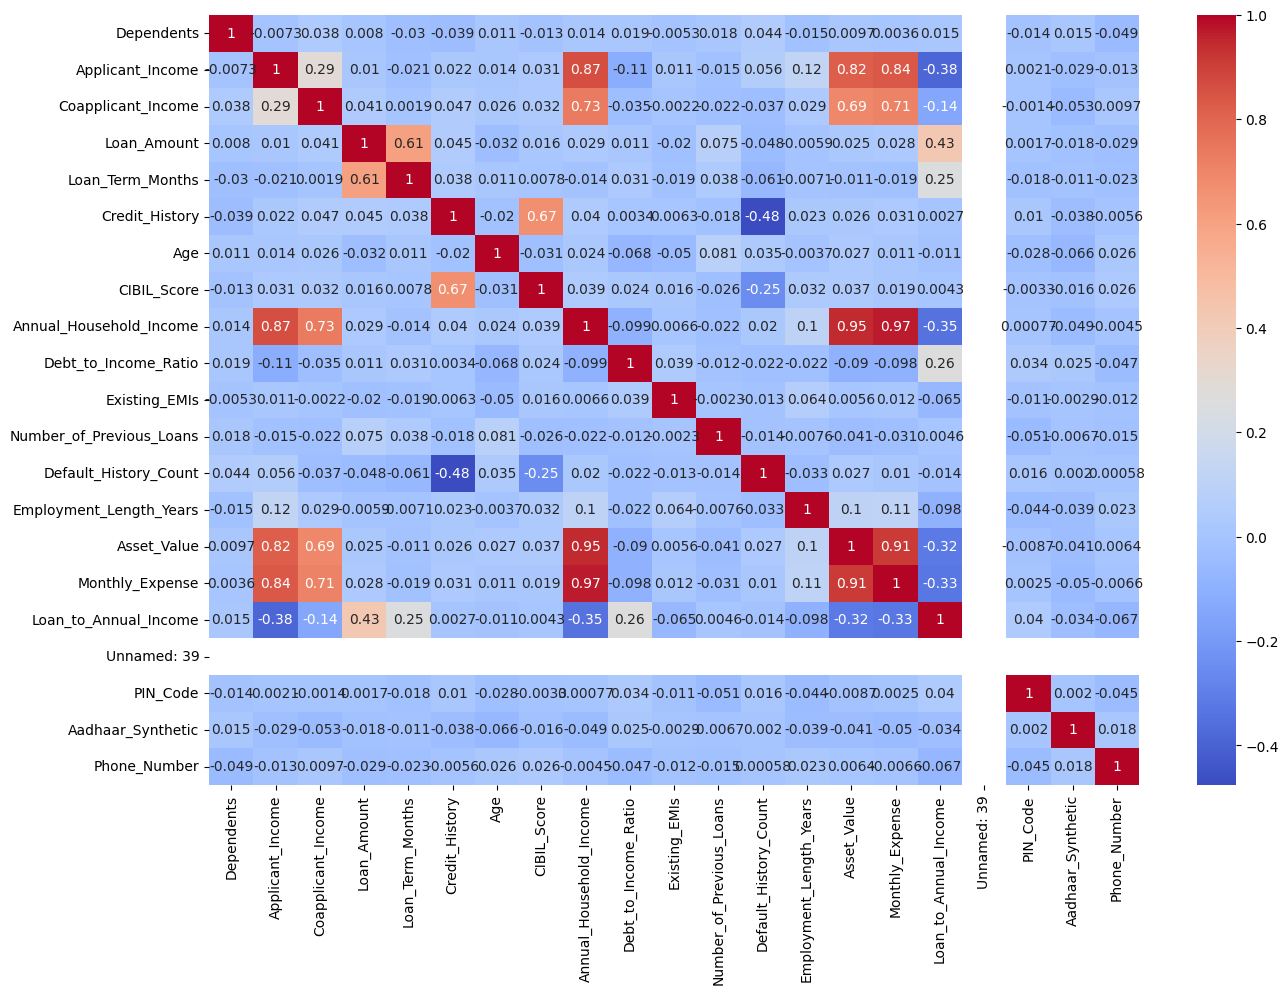

In [70]:
numeric_df = data.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

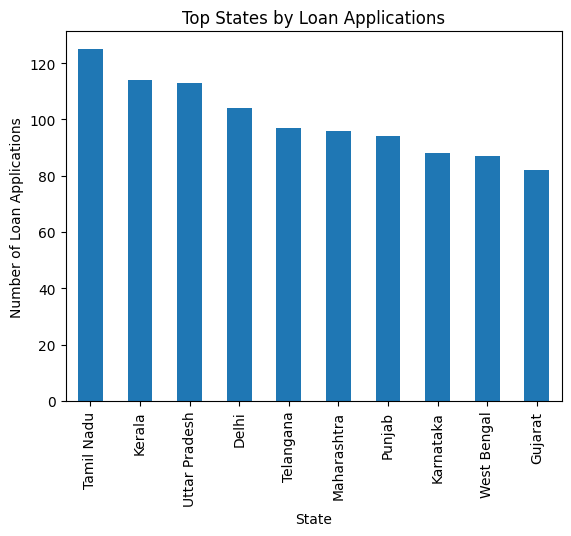

In [71]:
#State wise loan trends
data['State'].value_counts().head(10).plot(kind='bar')
plt.title("Top States by Loan Applications")
plt.xlabel("State")
plt.ylabel("Number of Loan Applications")
plt.show()

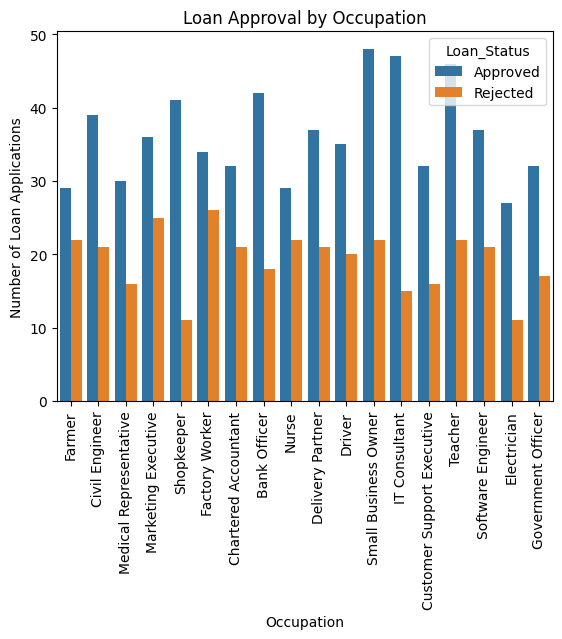

In [72]:
#Loan approval by occupation
sns.countplot(x='Occupation', hue='Loan_Status', data=data)
plt.xticks(rotation=90)
plt.title("Loan Approval by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Loan Applications")
plt.show()

# Summary of EDA

1. Dataset structure was analyzed.
2. Missing values were identified.
3. Duplicate records were checked.
4. Numerical and categorical columns were identified.
5. Multiple visualizations were created.
6. Relationships between variables were studied.

The dataset is now ready for preprocessing and machine learning model development.

# Data Preprocessing

## Objective

The objective of this section is to prepare the dataset for machine learning by performing:

1. Missing Value Handling
2. Encoding Categorical Features
3. Feature Scaling
4. Outlier Handling
5. Feature Selection
6. Train-Test Split

## Step 1: Missing Value Handling

Missing values can negatively affect model performance. Therefore, missing values are identified and handled appropriately.

In [73]:
data.isnull().sum()

,0
Loan_ID,0
Bank,0
Customer_Name,0
Gender,0
Married,0
Dependents,0
Education,0
Employment_Status,0
Applicant_Income,0
Coapplicant_Income,0


In [74]:
#Missing Value Handling
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [75]:
#Handling missing values for categorical columns
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [76]:
#Encoding Categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [79]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(data[num_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [80]:
#Outlier Handling
Q1 = data['Applicant_Income'].quantile(0.25)
Q3 = data['Applicant_Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = data[(data['Applicant_Income'] >= lower) &
        (data['Applicant_Income'] <= upper)]

In [82]:
data.to_csv("/content/drive/MyDrive/Machine_Learning/datasets/preprocessed_hdfc_loan_data.csv", index=False)